## **Proyect 1: MLP fraude financiero en casos de menos de 1000$ dolares**

- Juan Pablo Solis
- Andre Yatmian Jo Mai

### **1. IMPORTS Y CONFIGURACIÓN**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cpu


2. Carga del CSV ya preprocesado

In [ ]:

df_train_full = pd.read_csv('/content/drive/MyDrive/SDS/ieee_fraud_features_seleccionadas.csv')

feature_names = [c for c in df_train_full.columns if c != 'isFraud']
X_all = df_train_full[feature_names].values.astype(np.float32)
y_all = df_train_full['isFraud'].values.astype(np.float32)

print(f"Shape X: {X_all.shape}")
print(f"Shape y: {y_all.shape}")
print(f"Features: {len(feature_names)}")
print(f"Tasa de fraude: {y_all.mean()*100:.2f}%  →  {int(y_all.sum()):,} fraudes de {len(y_all):,}")

Shape X: (590540, 72)
Shape y: (590540,)
Features: 72
Tasa de fraude: 3.50%  →  20,663 fraudes de 590,540


3. Split train / Validación

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_all
)

print(f"Train : {X_train.shape}  | fraude: {y_train.mean()*100:.2f}%")
print(f"Val   : {X_val.shape}    | fraude: {y_val.mean()*100:.2f}%")

Train : (501959, 72)  | fraude: 3.50%
Val   : (88581, 72)    | fraude: 3.50%


4. Normalización - StandardScaler

In [ ]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print("StandardScaler aplicado.")
print(f"Media train (primeras 5 features): {X_train[:, :5].mean(axis=0).round(4)}")

StandardScaler aplicado.
Media train (primeras 5 features): [-0.  0. -0. -0.  0.]


5. Manejo del desbalance

In [ ]:

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight_val = n_neg / n_pos

print(f"Negativos (no fraude): {n_neg:,}")
print(f"Positivos (fraude):    {n_pos:,}")
print(f"pos_weight:            {pos_weight_val:.2f}x")

pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

Negativos (no fraude): 484,395
Positivos (fraude):    17,564
pos_weight:            27.58x


6. Data loaders

In [ ]:

BATCH_SIZE = 2048

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)}")

Batches — Train: 246 | Val: 44


### **Modelo MLP**
#### Arquitectura: 72 → 256 → 128 → 64 → 32 → 1

In [ ]:


class FraudMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

input_dim = X_train.shape[1]
model     = FraudMLP(input_dim=input_dim).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nInput dim      : {input_dim}")
print(f"Parámetros     : {total_params:,}")

FraudMLP(
  (net): Sequential(
    (0): Linear(in_features=72, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)

Input dim      : 72
Parámetros     : 62,849


In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)


### **Entrenamiento**

In [ ]:

EPOCHS        = 50
PATIENCE      = 8
best_val_loss = np.inf
patience_cnt  = 0

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # --- ENTRENAMIENTO ---
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # --- VALIDACIÓN ---
    model.eval()
    val_loss  = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item()
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())
    val_loss /= len(val_loader)

    roc_epoch = roc_auc_score(all_labels, all_probs)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val ROC-AUC: {roc_epoch:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), 'best_mlp_ieee.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping en epoch {epoch}")
            break

print(f"\nMejor val_loss: {best_val_loss:.4f}")

Epoch 01/50 | Train Loss: 0.9618 | Val Loss: 0.8749 | Val ROC-AUC: 0.8660
Epoch 05/50 | Train Loss: 0.8045 | Val Loss: 0.7860 | Val ROC-AUC: 0.8940
Epoch 10/50 | Train Loss: 0.7378 | Val Loss: 0.7230 | Val ROC-AUC: 0.9110
Epoch 15/50 | Train Loss: 0.6974 | Val Loss: 0.6900 | Val ROC-AUC: 0.9189
Epoch 20/50 | Train Loss: 0.6704 | Val Loss: 0.6711 | Val ROC-AUC: 0.9241
Epoch 25/50 | Train Loss: 0.6518 | Val Loss: 0.6629 | Val ROC-AUC: 0.9262
Epoch 30/50 | Train Loss: 0.6278 | Val Loss: 0.6500 | Val ROC-AUC: 0.9303
Epoch 35/50 | Train Loss: 0.6118 | Val Loss: 0.6386 | Val ROC-AUC: 0.9320
Epoch 40/50 | Train Loss: 0.6081 | Val Loss: 0.6297 | Val ROC-AUC: 0.9339
Epoch 45/50 | Train Loss: 0.5754 | Val Loss: 0.6333 | Val ROC-AUC: 0.9369
Epoch 50/50 | Train Loss: 0.5596 | Val Loss: 0.6222 | Val ROC-AUC: 0.9385

Mejor val_loss: 0.6222


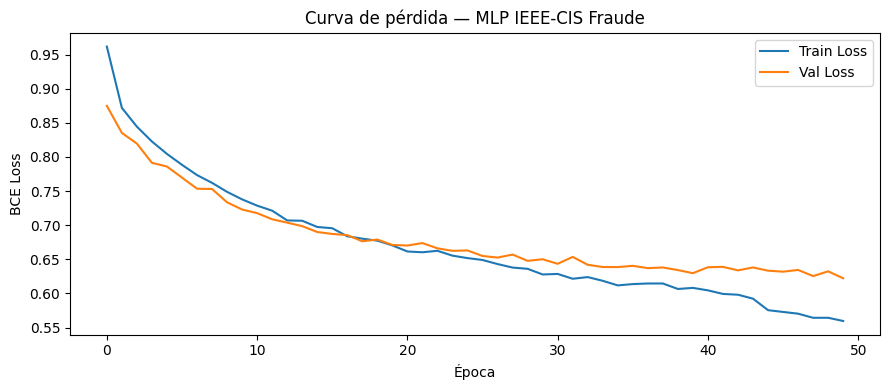

In [ ]:

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.title('Curva de pérdida — MLP IEEE-CIS Fraude')
plt.legend()
plt.tight_layout()
plt.show()

La curva de pérdida muestra que el modelo MLP aprendió correctamente durante el entrenamiento, ya que tanto la pérdida de entrenamiento como la de validación disminuyen progresivamente a lo largo de las épocas. Además, ambas curvas se mantienen cercanas, lo que indica que el modelo logra generalizar adecuadamente sin presentar un sobreajuste significativo

### **Evaluacion**

In [ ]:

model.load_state_dict(torch.load('best_mlp_ieee.pt', map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc  = average_precision_score(all_labels, all_probs)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

# Umbral óptimo por F1
thresholds_range = np.arange(0.1, 0.9, 0.01)
f1_scores = []
for t in thresholds_range:
    preds_t = (all_probs >= t).astype(int)
    from sklearn.metrics import f1_score
    f1_scores.append(f1_score(all_labels, preds_t, zero_division=0))

best_threshold = thresholds_range[np.argmax(f1_scores)]
print(f"\nUmbral óptimo (mejor F1): {best_threshold:.2f}")

preds = (all_probs >= best_threshold).astype(int)
print("\n=== Reporte de clasificación ===")
print(classification_report(all_labels, preds,
                             target_names=['No Fraude', 'Fraude'],
                             zero_division=0))

ROC-AUC : 0.9385
PR-AUC  : 0.6362

Umbral óptimo (mejor F1): 0.89

=== Reporte de clasificación ===
              precision    recall  f1-score   support

   No Fraude       0.98      0.99      0.99     85482
      Fraude       0.66      0.56      0.61      3099

    accuracy                           0.97     88581
   macro avg       0.82      0.78      0.80     88581
weighted avg       0.97      0.97      0.97     88581



Matriz de confusión, curva ROC y curva ROC

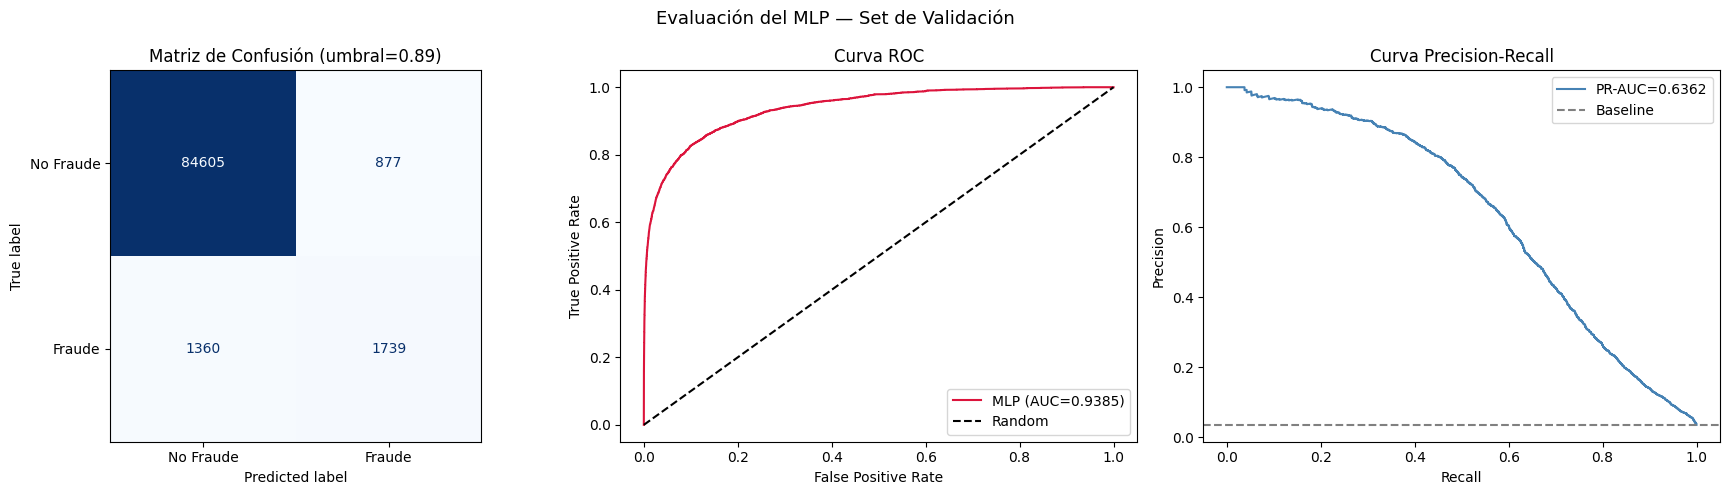

TN: 84,605 | FP: 877 | FN: 1,360 ← fraudes no detectados | TP: 1,739 ← fraudes detectados


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
cm = confusion_matrix(all_labels, preds)
ConfusionMatrixDisplay(cm, display_labels=['No Fraude', 'Fraude']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión (umbral={best_threshold:.2f})')

# Curva ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='crimson', label=f'MLP (AUC={roc_auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
axes[2].plot(recall, precision, color='steelblue', label=f'PR-AUC={pr_auc:.4f}')
axes[2].axhline(all_labels.mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Curva Precision-Recall')
axes[2].legend()

plt.suptitle('Evaluación del MLP — Set de Validación', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn:,} | FP: {fp:,} | FN: {fn:,} ← fraudes no detectados | TP: {tp:,} ← fraudes detectados")

La evaluación del modelo MLP muestra un desempeño sólido en la detección de fraude. La matriz de confusión evidencia que el modelo clasificó correctamente la mayoría de transacciones legítimas (84,605) y detectó 1,739 fraudes, aunque aún existen 1,360 fraudes no detectados (False Negatives). La curva ROC presenta un AUC de 0.9385, indicando una alta capacidad de discriminación entre clases fraudulentas y no fraudulentas. Asimismo, la curva Precision-Recall obtiene un PR-AUC de 0.6362, resultado relevante considerando el desbalance extremo del dataset, donde los casos de fraude representan una minoría. En conjunto, los resultados indican que el MLP logró aprender patrones útiles para identificar actividades fraudulentas con buena capacidad de generalización.